# Curly Vectors

## UltraPlot

Wrapper for `matploblib` for the function ["curved_quiver"](https://ultraplot.readthedocs.io/en/latest/api/ultraplot.axes.PlotAxes.html#ultraplot.axes.PlotAxes.curved_quiver)

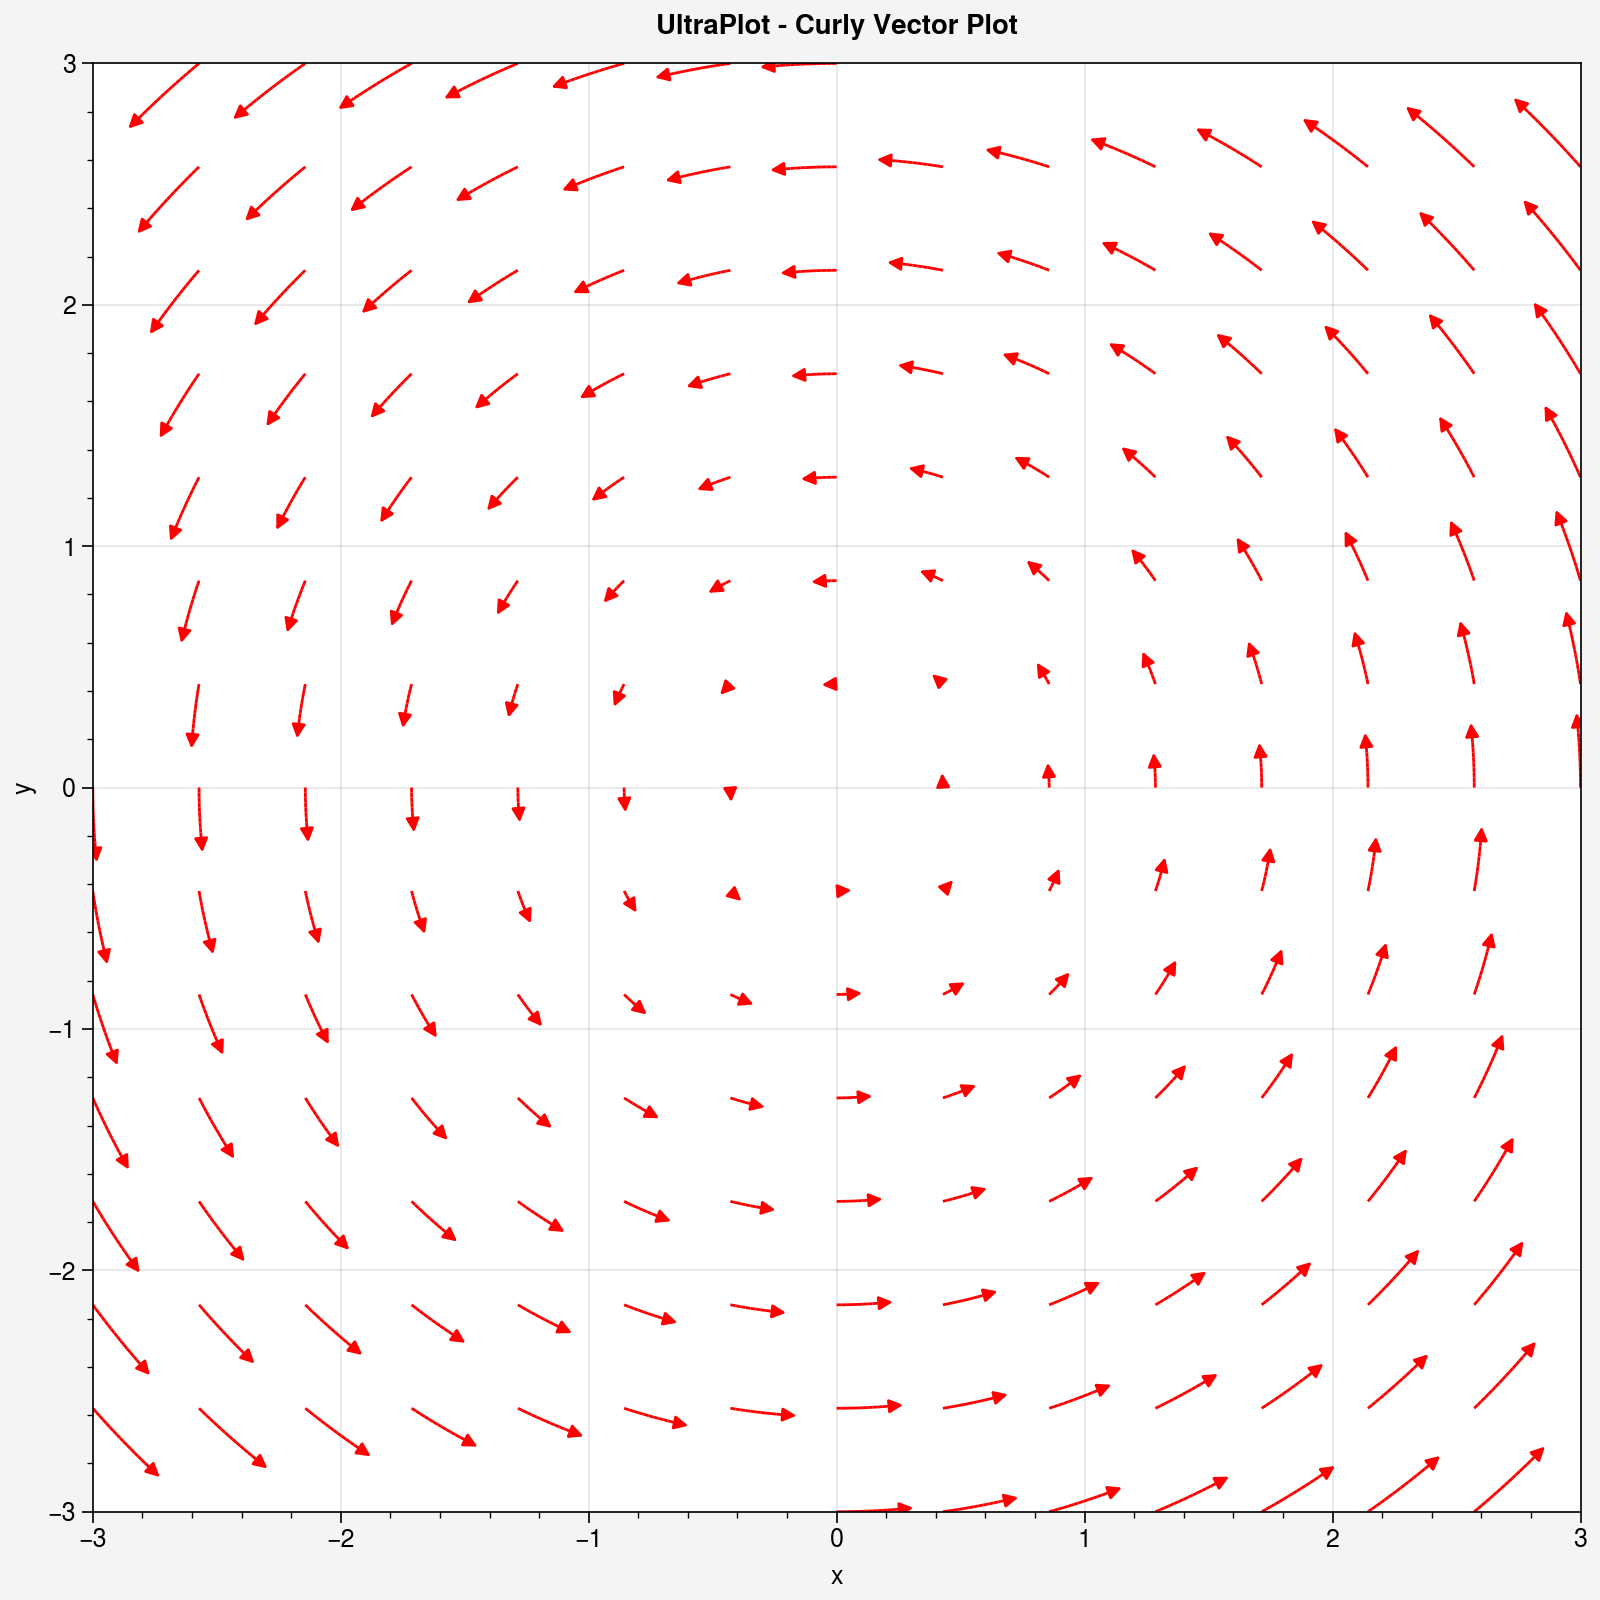

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import ultraplot as uplot

# Sample data
x = np.linspace(-3, 3, 30)
y = np.linspace(-3, 3, 30)
X, Y = np.meshgrid(x, y)
v = X  # the y-component
u = -Y # the x-component

# plot
fig, ax = uplot.subplot(figsize=(8, 8))

# x, y = Grid coordinates
# u, v = Vector components
# color = color of the arrows
# density = controls how dense the arrows are displayed as
# grains = number of seed points in x and y
# linewidth = width of arrows
# cmap, norm = colormap and normalization for array colors
# colorbar: add colorbar
# arrowsize = arrow size
# arrowstyle = arrow style
# transform = matplotlib transform
# zorder = z-order for lines/arrows
# start_points = starting points for the strealines (N, 2) array

ax.curved_quiver(x=X, y=Y, u=u, v=v,
                 color= "red",
                 arrow_at_end=True,
                 arrowsize=1,
                 linewidth=1,
                 density=10) 

ax.format(
    suptitle='UltraPlot - Curly Vector Plot',
    grid=True,
    xlabel='x', ylabel='y'
)

plt.show()

## Skyborn

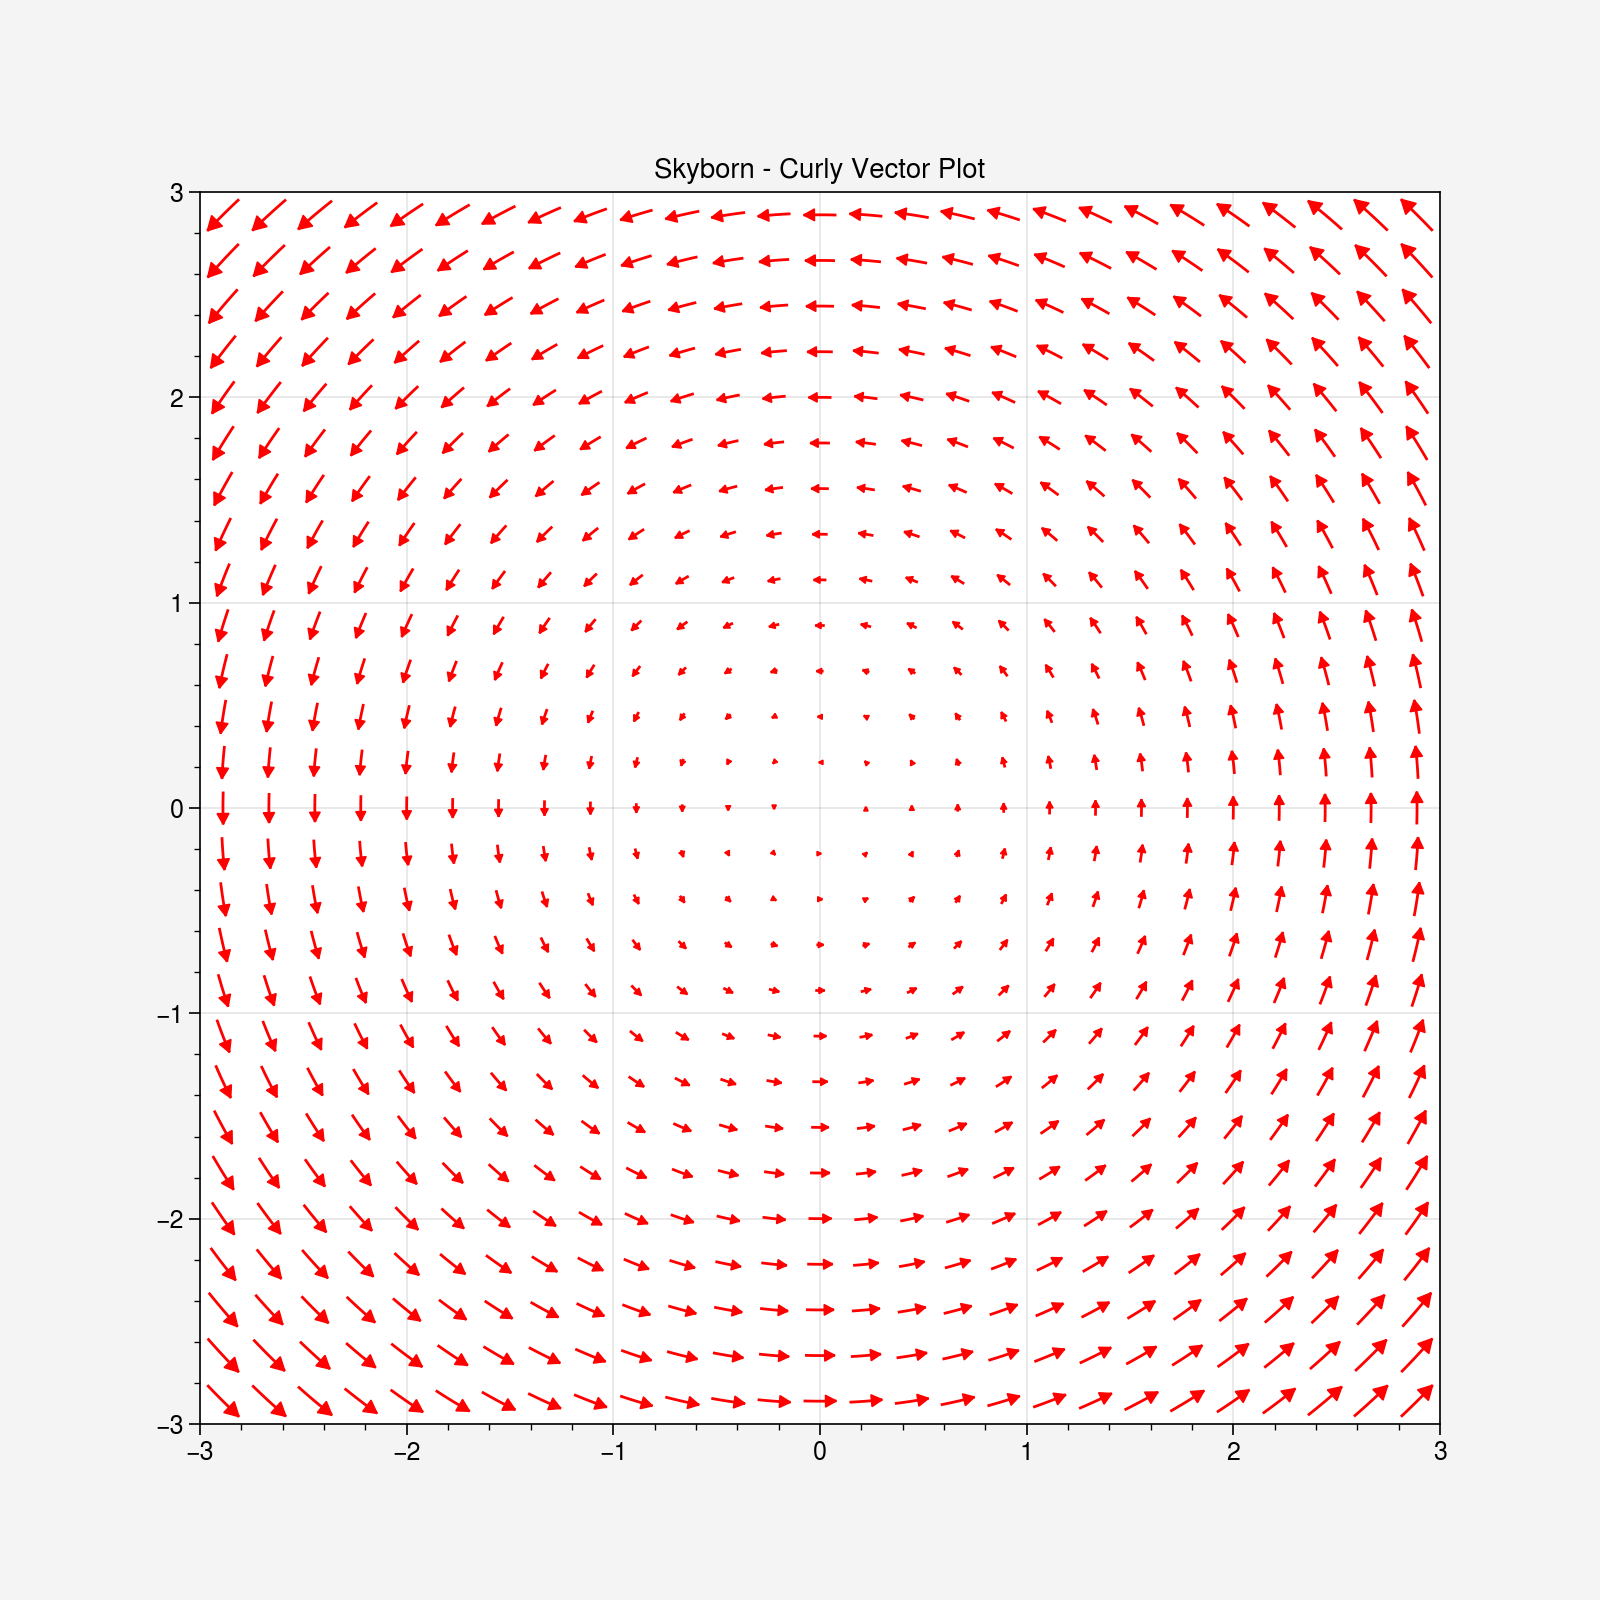

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from skyborn.plot import curly_vector

# Sample data
x = np.linspace(-3, 3, 30)
y = np.linspace(-3, 3, 30)
X, Y = np.meshgrid(x, y)
v = X  # the y-component
u = -Y # the x-component

# plot
fig, ax = plt.subplots(figsize=(8, 8))
plt.title("Skyborn - Curly Vector Plot")

cv = curly_vector(X, Y, u, v,
                  ax=ax,
                  color="red",
                  density=0.9,
                  arrowstyle="-|>",
                  arrowsize=1,
                  linewidth=1)

ax.set_xlim(-3, 3)
ax.set_ylim(-3, 3)

plt.show()

# NCL Vector Example 1
- "Plot U & V vector over SST"

GeoCAT-Examples:
![vector_1](https://geocat-examples.readthedocs.io/en/latest/_images/sphx_glr_NCL_vector_1_001.png)

# NCL Vector Example 3
- "Plot U and V vectors globally"

GeoCAT-Examples:
![vector_3](https://geocat-examples.readthedocs.io/en/latest/_images/sphx_glr_NCL_vector_3_001.png)

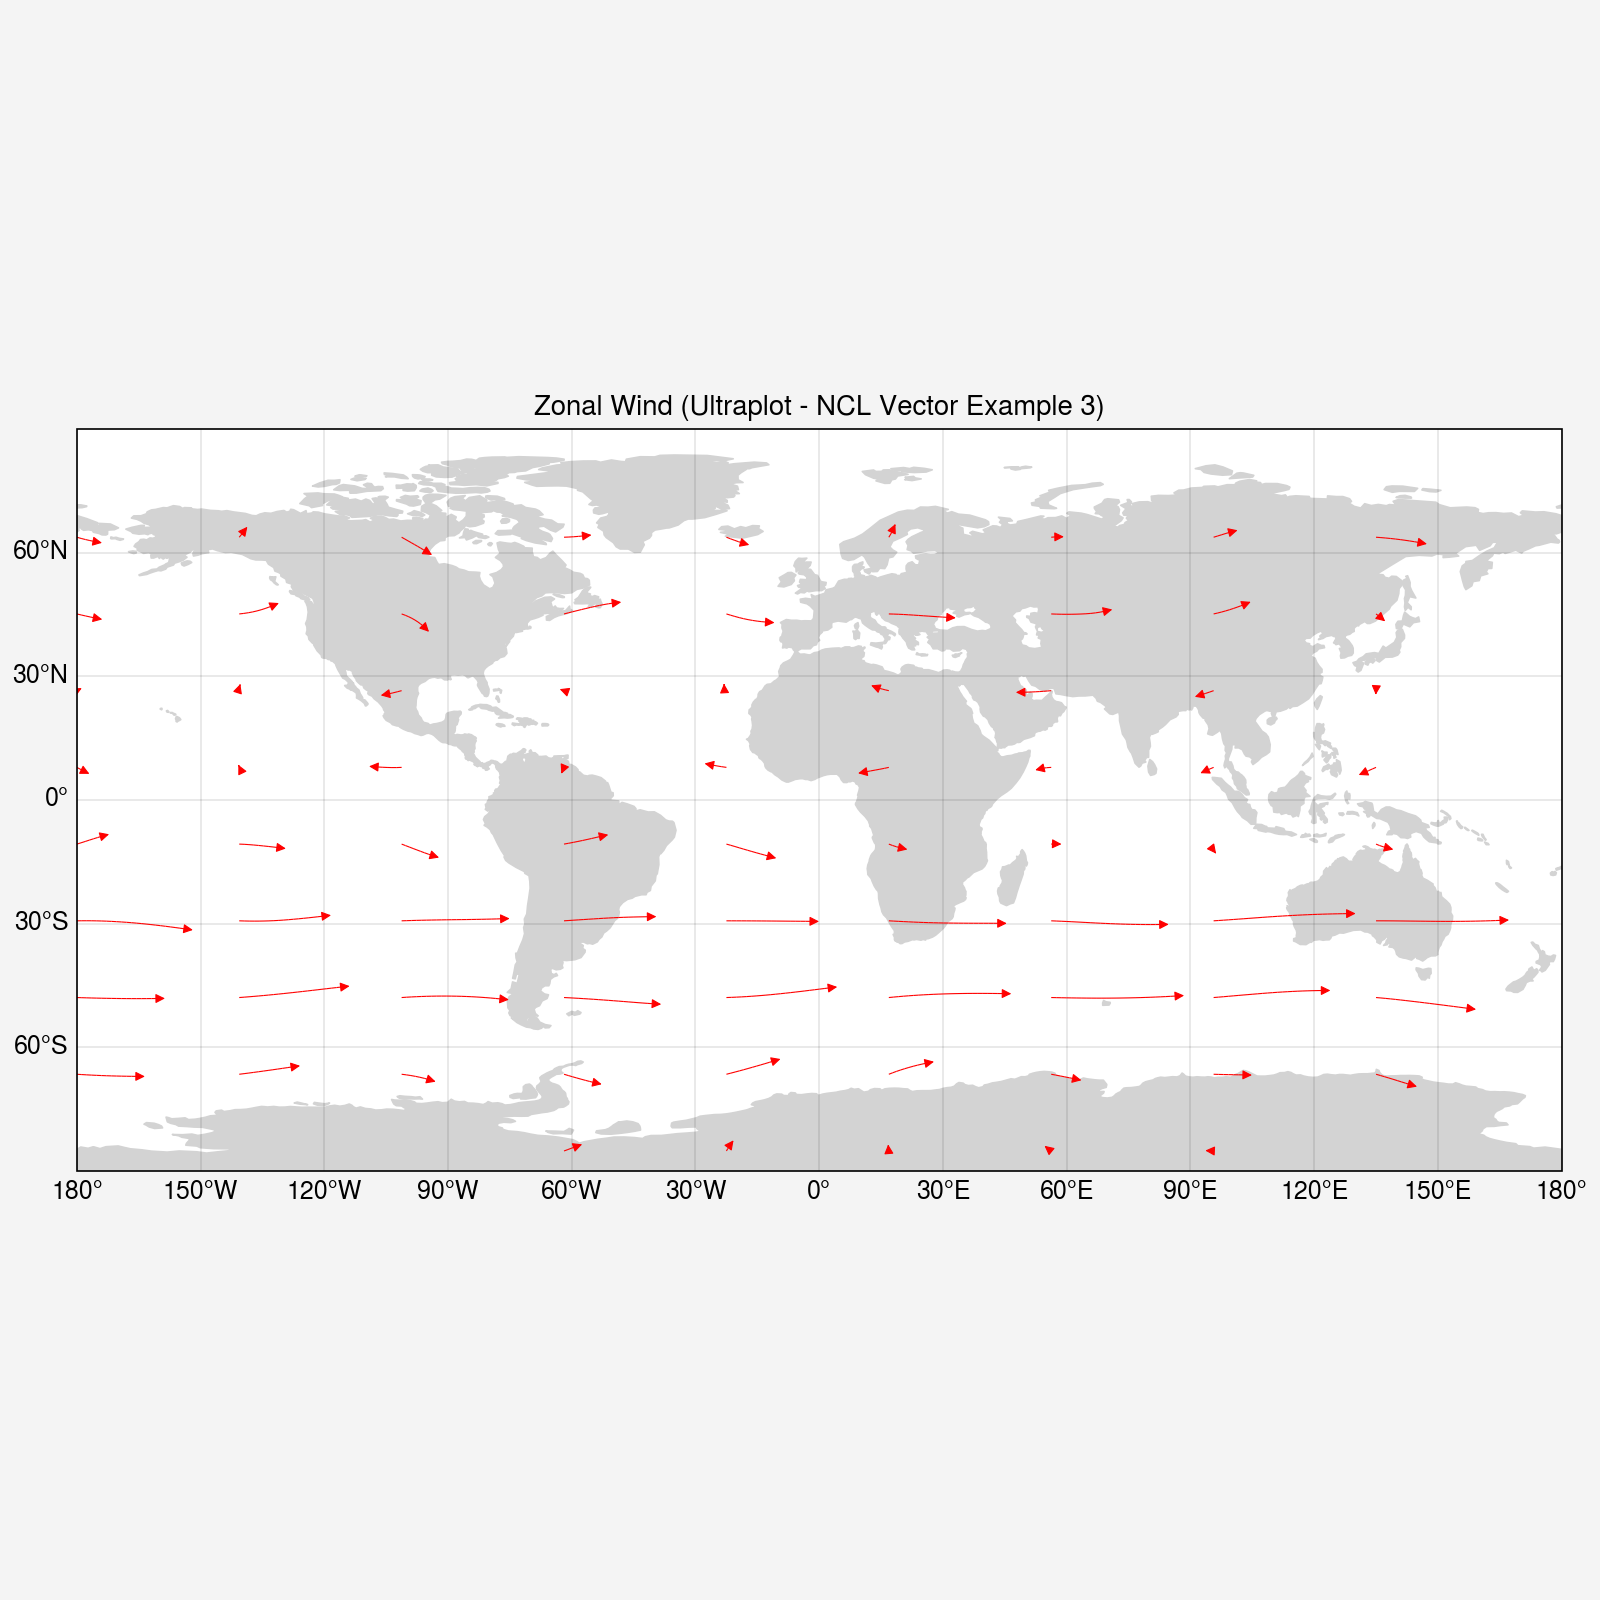

In [37]:
# https://geocat-examples.readthedocs.io/en/latest/gallery/Vectors/NCL_vector_3.html
import xarray as xr
import geocat.datafiles as gdf
import cartopy
from matplotlib import pyplot as plt

file_in = xr.open_dataset(gdf.get("netcdf_files/uv300.nc"))
ds = file_in.isel(time=1, lon=slice(0, -1, 3), lat=slice(1, -1, 3))

# plot
fig, ax = uplot.subplot(figsize=(8, 8), proj="cyl")

ax.add_feature(
    cartopy.feature.LAND, edgecolor='lightgray', facecolor='lightgray', zorder=0
)

ax.curved_quiver(ds['lon'].values, ds['lat'].values, ds['U'].values, ds['V'].values,
                 color= "red",
                 arrow_at_end=True,
                 arrowsize=0.7,
                 linewidth=0.4,
                 density=10,
                 grains=10) 

ax.format(
    land=False,
    lonlabels='bottom',      # place labels on the bottom (longitude)
    latlabels='left',        # place labels on the left (latitude)
    lonlocator=30,           # Labels every 30 degrees (longitude)
    latlocator=30,           # Labels every 30 degrees (latitude)
    lonformatter='deglon',   # Format to degrees East/West
    latformatter='deglat'    # Format to degrees North/South
)

plt.title("Zonal Wind (Ultraplot - NCL Vector Example 3)")
plt.show()

# NCL Vector Example 4
- "Plot U & V vectors globally, colored according to temperatures

GeoCAT-Examples:
![vector_4](https://geocat-examples.readthedocs.io/en/latest/_images/sphx_glr_NCL_vector_4_001.png)

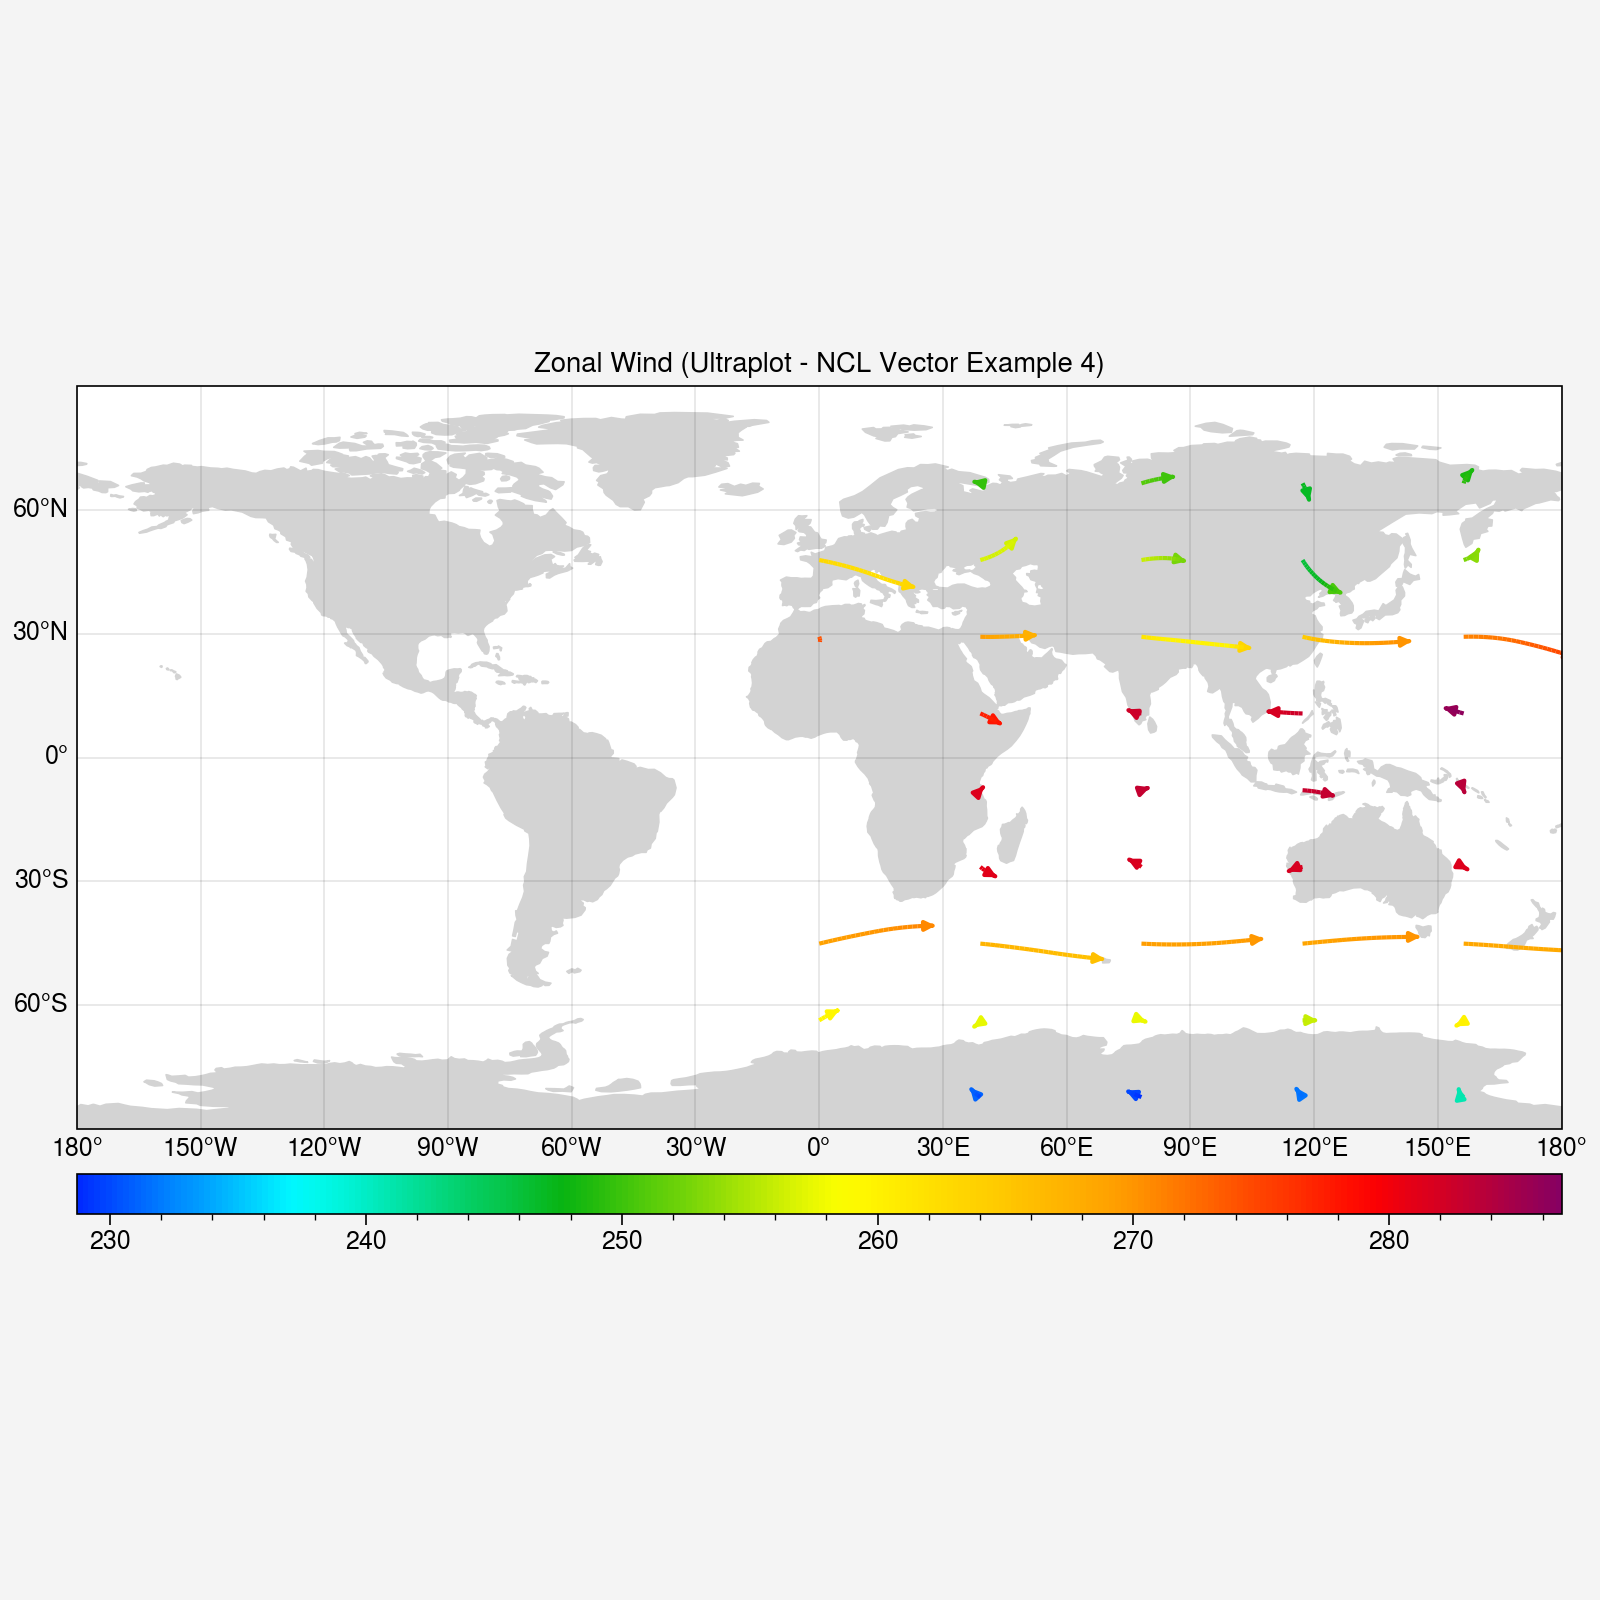

In [62]:
# https://geocat-examples.readthedocs.io/en/latest/gallery/Vectors/NCL_vector_3.html
import xarray as xr
import geocat.datafiles as gdf
import cartopy
from matplotlib import pyplot as plt
import cmaps
import geocat.viz as gv

file_in = xr.open_dataset(gdf.get("netcdf_files/83.nc"))
ds = file_in.isel(time=0, lev=12, lon=slice(0, -1, 5), lat=slice(2, -1, 3))

# plot
fig, ax = uplot.subplot(figsize=(8, 8), proj="cyl")

ax.add_feature(
    cartopy.feature.LAND, edgecolor='lightgray', facecolor='lightgray', zorder=0
)


cmap = gv.truncate_colormap(cmaps.BlAqGrYeOrReVi200, minval=0.03, maxval=0.95, n=16)

cq = ax.curved_quiver(ds['lon'].values, ds['lat'].values, ds['U'].values, ds['V'].values,
                 color=ds["T"].values,
                 cmap=cmap,
                 colorbar="bottom",
                 arrow_at_end=True,
                 arrowsize=0.7,
                 density=10,
                 grains=10) 


ax.format(
    title="Zonal Wind (Ultraplot - NCL Vector Example 4)",
    land=False,
    lonlabels="bottom",      # place labels on the bottom (longitude)
    latlabels="left",        # place labels on the left (latitude)
    lonlocator=30,           # Labels every 30 degrees (longitude)
    latlocator=30,           # Labels every 30 degrees (latitude)
    lonformatter="deglon",   # Format to degrees East/West
    latformatter="deglat",   # Format to degrees North/South
    
)

plt.show()